In [1]:
import pandas as pd
import matplotlib.pyplot as plt

lazio = pd.read_csv("../data/lazio_dataset_completo.csv")

lazio["conversione_tiri"] = lazio["gol_fatti"] / lazio["tiri"]
lazio["precisione_tiri"] = lazio["tiri_in_porta"] / lazio["tiri"]

confronto = lazio.groupby("stagione").agg({
    "gol_fatti": "mean",
    "gol_subiti": "mean",
    "xG": "mean",
    "tiri": "mean",
    "tiri_in_porta": "mean",
    "conversione_tiri": "mean",
    "precisione_tiri": "mean"
})

print(confronto)

           gol_fatti  gol_subiti        xG       tiri  tiri_in_porta  \
stagione                                                               
2019_2020   2.157895    0.894737  1.891053  16.578947       6.421053   
2024_2025   1.736842    1.421053  1.873158  13.736842       5.263158   

           conversione_tiri  precisione_tiri  
stagione                                      
2019_2020          0.132871         0.402610  
2024_2025          0.130581         0.407182  


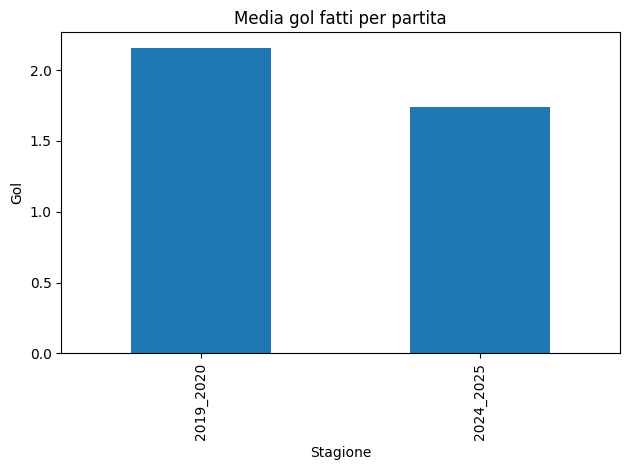

In [2]:
plt.figure()

confronto["gol_fatti"].plot(kind="bar")

plt.title("Media gol fatti per partita")
plt.ylabel("Gol")
plt.xlabel("Stagione")

plt.tight_layout()
plt.savefig("../immagini/media_gol_fatti.png")

plt.show()

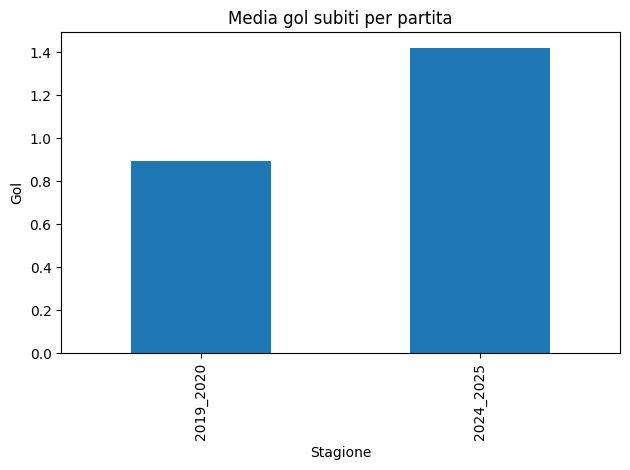

In [3]:
plt.figure()

confronto["gol_subiti"].plot(kind="bar")

plt.title("Media gol subiti per partita")
plt.ylabel("Gol")
plt.xlabel("Stagione")

plt.tight_layout()
plt.savefig("../immagini/media_gol_subiti.png")

plt.show()

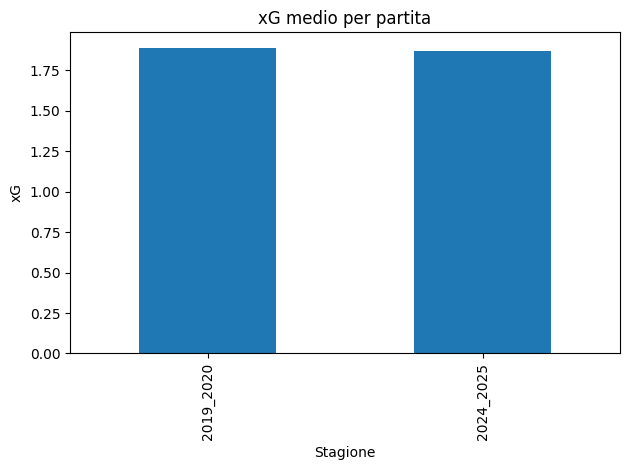

In [4]:
plt.figure()

confronto["xG"].plot(kind="bar")

plt.title("xG medio per partita")
plt.ylabel("xG")
plt.xlabel("Stagione")

plt.tight_layout()
plt.savefig("../immagini/xg_medio.png")

plt.show()

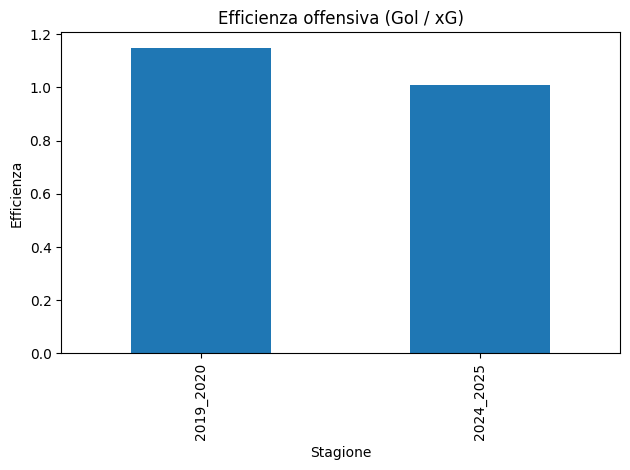

In [5]:
lazio["efficienza_offensiva"] = lazio["gol_fatti"] / lazio["xG"]

eff = lazio.groupby("stagione")["efficienza_offensiva"].mean()
plt.figure()

eff.plot(kind="bar")

plt.title("Efficienza offensiva (Gol / xG)")
plt.ylabel("Efficienza")
plt.xlabel("Stagione")

plt.tight_layout()
plt.savefig("../immagini/efficienza_offensiva_media.png")

plt.show()

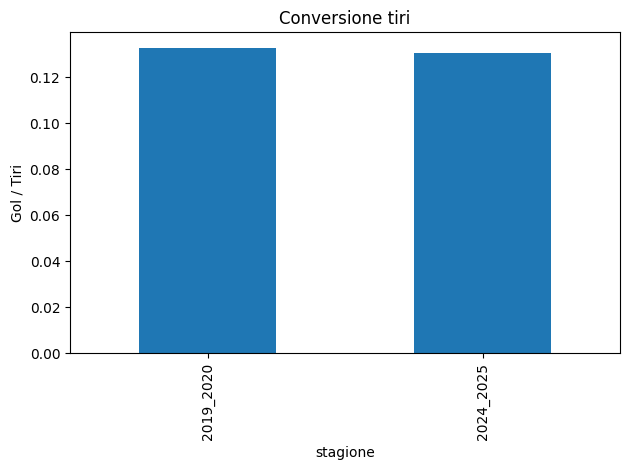

In [6]:
lazio["conversione_tiri"] = lazio["gol_fatti"] / lazio["tiri"]

conv = lazio.groupby("stagione")["conversione_tiri"].mean()

plt.figure()

conv.plot(kind="bar")

plt.title("Conversione tiri")
plt.ylabel("Gol / Tiri")

plt.tight_layout()
plt.savefig("../immagini/conversione_tiri.png")

plt.show()

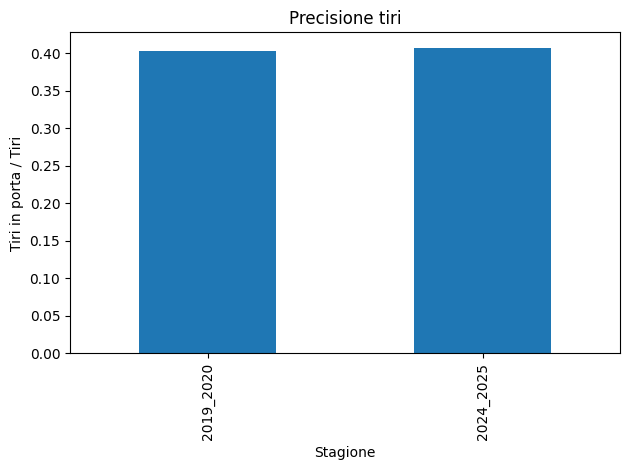

In [7]:
lazio["precisione_tiri"] = lazio["tiri_in_porta"] / lazio["tiri"]

prec = lazio.groupby("stagione")["precisione_tiri"].mean()

plt.figure()

prec.plot(kind="bar")

plt.title("Precisione tiri")
plt.ylabel("Tiri in porta / Tiri")
plt.xlabel("Stagione")

plt.tight_layout()
plt.savefig("../immagini/precisione_tiri.png")

plt.show()

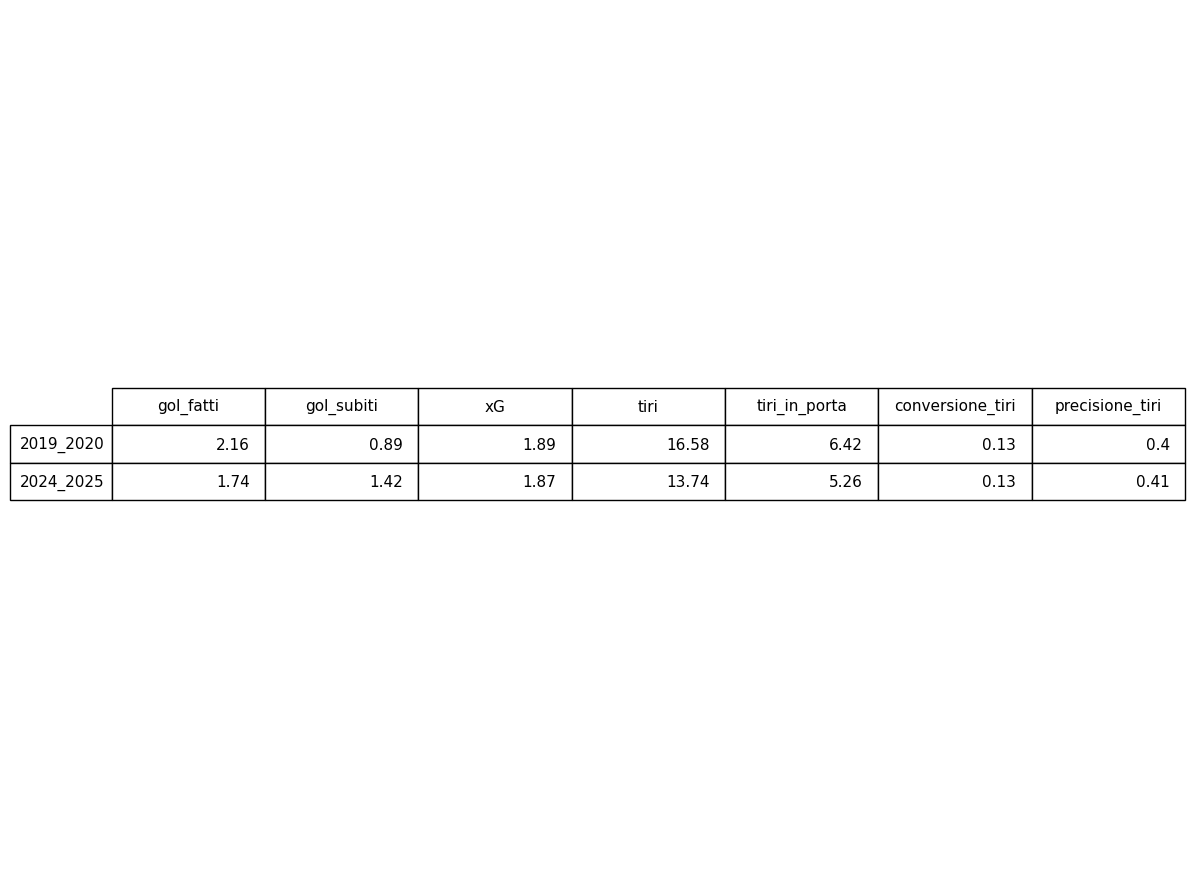

In [12]:
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")

table = ax.table(
    cellText=confronto.round(2).values,
    colLabels=confronto.columns,
    rowLabels=confronto.index,
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.6, 1.8)

plt.tight_layout()
plt.savefig("../immagini/tabella_confronto.png", bbox_inches="tight", dpi=150)
plt.show()